# Anime Recommender System - Model 1: Linear Regression

## I. Setup, Data Loading & Health Checks

This section imports libraries, loads the dataset, and runs strict health checks to avoid crashes from faulty dataframes.

Defensive checks include:
- safe CSV loading with `try-except`
- strict datetime parsing with invalid-date removal
- explicit handling of `np.inf` / `-np.inf`
- NaN remediation through deterministic imputation
- final assertion that no missing values remain before modeling

In [17]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_theme(style="darkgrid")

SEED = 42
np.random.seed(SEED)

DATE_COL = "last_updated_dt"

INPUT_CANDIDATES = [
    Path("processed-data/anime_ml_ready.csv"),
    Path("processed-data/anime.csv"),
]

src_path = next((p for p in INPUT_CANDIDATES if p.exists()), None)
if src_path is None:
    raise FileNotFoundError(
        f"No dataset found. Checked: {[str(p) for p in INPUT_CANDIDATES]}"
    )

try:
    df = pd.read_csv(src_path, low_memory=False)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Dataset file not found at runtime: {src_path.resolve()}"
    ) from e
except Exception as e:
    raise RuntimeError(f"Failed to read CSV safely: {e}") from e

if DATE_COL not in df.columns:
    raise ValueError(f"Required datetime column missing: {DATE_COL}")

# Pain Point 1: robust datetime parsing
before_date_parse = len(df)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).copy()
after_date_parse = len(df)

if df.empty:
    raise ValueError(
        "All rows were dropped after datetime parsing. "
        "Check date format or source file integrity."
    )


def strict_dataframe_health_check(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Replace inf with NaN, impute all NaNs, and enforce zero missing values."""
    checked = dataframe.copy()

    # Pain Point 2: handle infinities and NaNs deterministically
    checked = checked.replace([np.inf, -np.inf], np.nan)

    numeric_cols = checked.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric_cols = [c for c in checked.columns if c not in numeric_cols]

    for col in numeric_cols:
        med = checked[col].median()
        if pd.isna(med):
            med = 0.0
        checked[col] = checked[col].fillna(med)

    for col in non_numeric_cols:
        mode_series = checked[col].mode(dropna=True)
        fallback = mode_series.iloc[0] if not mode_series.empty else "UNKNOWN"
        checked[col] = checked[col].fillna(fallback)

    assert checked.isnull().sum().sum() == 0, "Health check failed: NaNs remain in dataframe."
    return checked


df = strict_dataframe_health_check(df)

print(f"Loaded dataset: {src_path.resolve()}")
print(f"Rows before datetime parse: {before_date_parse:,}")
print(f"Rows after datetime parse : {after_date_parse:,}")
print(f"Final shape after health checks: {df.shape}")
print(f"Date range: {df[DATE_COL].min()} -> {df[DATE_COL].max()}")
print("\nData preview:")
print(df.head())

Loaded dataset: C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\01-actual-folder\STINTSYMajorOutput\processed-data\anime_ml_ready.csv
Rows before datetime parse: 91,209
Rows after datetime parse : 90,544
Final shape after health checks: (90544, 18)
Date range: 2006-10-09 04:41:50 -> 2018-05-20 23:47:25

Data preview:
   username  anime_id  my_score  implicit_positive  my_status  \
0  --ALEX--      2685        10                  1          2   
1  --ALEX--       355         9                  1          2   
2  --ALEX--      1066         8                  1          2   
3  --ALEX--      3221         7                  1          2   
4  --ALEX--      3712         7                  1          2   

      last_updated_dt  episodes  score  popularity  favorites  user_watching  \
0 2008-06-20 22:29:45         3   8.40        1209        830              9   
1 2008-07-19 06:30:29        24   7.66         144       5146              9   
2 2008-07-21 08:32:42         4   7.19 

## II. Feature Selection & Multicollinearity

We define a baseline, interpretable feature set focused on robust numeric predictors that are broadly available.

Included features:

| Feature | Justification |
|---|---|
| episodes | Basic content-length signal tied to user commitment and rating behavior. |
| score | Community-level quality prior; strong baseline predictor for explicit scores. |
| popularity | Exposure and mainstream visibility proxy. |
| favorites | Fan-intensity signal often correlated with high ratings. |
| user_watching | Current consumption behavior proxy at user level. |
| user_completed | User experience/intensity indicator. |
| user_onhold | Incomplete-consumption behavior signal. |
| user_dropped | Negative engagement tendency signal. |
| user_plantowatch | Future-intent backlog proxy. |
| user_days_spent_watching | Overall user activity/intensity proxy. |

**Note:**
Linearly dependent features are excluded on purpose. For example, if we engineer `user_total_status = user_watching + user_completed + user_onhold + user_dropped + user_plantowatch`, then including both `user_total_status` and all components creates near-perfect linear dependence. That can make $X^TX$ ill-conditioned, destabilize coefficients, and corrupt interpretability.

In [18]:
TARGET_COL = "my_score"

candidate_feature_cols = [
    "episodes",
    "score",
    "popularity",
    "favorites",
    "user_watching",
    "user_completed",
    "user_onhold",
    "user_dropped",
    "user_plantowatch",
    "user_days_spent_watching",
]

FEATURE_COLS = [c for c in candidate_feature_cols if c in df.columns]

missing_required = [c for c in [TARGET_COL, DATE_COL] if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required core columns: {missing_required}")

if len(FEATURE_COLS) < 3:
    raise ValueError(
        f"Insufficient usable features found. Available: {FEATURE_COLS}"
    )

# Coerce model columns to numeric for mathematical safety
for col in FEATURE_COLS + [TARGET_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Re-run health check after coercion
if df[FEATURE_COLS + [TARGET_COL]].isnull().sum().sum() > 0:
    df = strict_dataframe_health_check(df)

print("Target column:", TARGET_COL)
print("Selected features:")
for f in FEATURE_COLS:
    print("-", f)
print(f"Total selected features: {len(FEATURE_COLS)}")

Target column: my_score
Selected features:
- episodes
- score
- popularity
- favorites
- user_watching
- user_completed
- user_onhold
- user_dropped
- user_plantowatch
- user_days_spent_watching
Total selected features: 10


## III. Train / Validation / Test Split (Time-Series Safe)

A chronological split is mandatory for time-dependent data.

If we randomize rows, the model may learn patterns that indirectly include future information, which creates **Data Leakage**. This makes validation metrics look better than true production performance.

To prevent leakage:
- sort strictly by the datetime column
- split by index slices in temporal order
- never use random shuffling or `train_test_split` for this scenario

Split summary (chronological):
- Train rows: 63,380 | Date range: 2006-10-09 04:41:50 -> 2015-10-01 11:21:18
- Val rows  : 13,582 | Date range: 2015-10-01 11:59:42 -> 2016-12-10 00:28:35
- Test rows : 13,582 | Date range: 2016-12-10 01:16:59 -> 2018-05-20 23:47:25


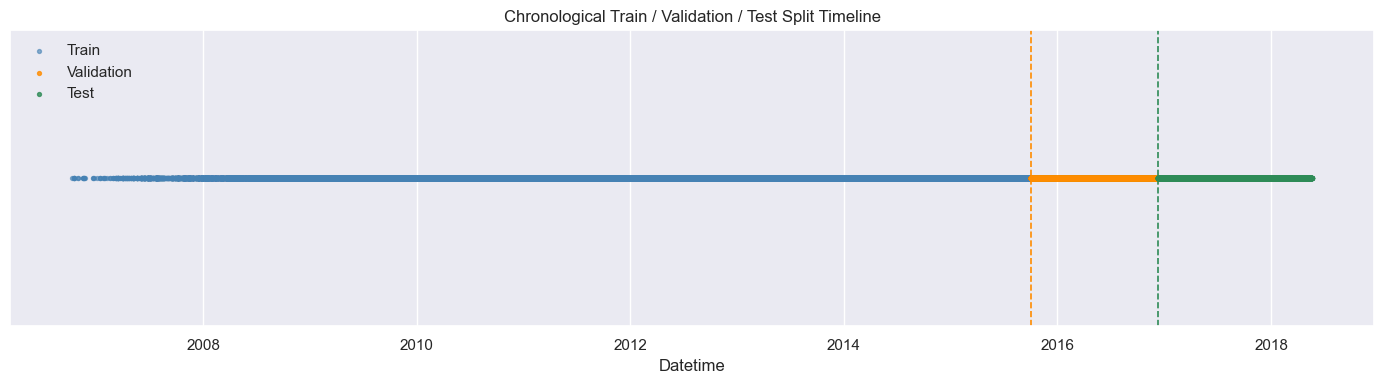

In [22]:
# Pain Point 4: strict chronological sorting before split
df_sorted = df.sort_values(DATE_COL, kind="mergesort").reset_index(drop=True)

n = len(df_sorted)
if n < 50:
    raise ValueError(f"Dataset too small for robust splitting (n={n}).")

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_sorted.iloc[:train_end].copy()
val_df = df_sorted.iloc[train_end:val_end].copy()
test_df = df_sorted.iloc[val_end:].copy()

if train_df.empty or val_df.empty or test_df.empty:
    raise ValueError(
        "One split is empty. Adjust split ratios or verify dataset size."
    )


def split_range(part: pd.DataFrame, date_col: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    return part[date_col].min(), part[date_col].max()

train_min, train_max = split_range(train_df, DATE_COL)
val_min, val_max = split_range(val_df, DATE_COL)
test_min, test_max = split_range(test_df, DATE_COL)

# Visual proof of non-overlap
assert train_max <= val_min, "Temporal overlap detected between Train and Val."
assert val_max <= test_min, "Temporal overlap detected between Val and Test."

print("Split summary (chronological):")
print(f"- Train rows: {len(train_df):,} | Date range: {train_min} -> {train_max}")
print(f"- Val rows  : {len(val_df):,} | Date range: {val_min} -> {val_max}")
print(f"- Test rows : {len(test_df):,} | Date range: {test_min} -> {test_max}")

# Timeline visualization
plt.figure(figsize=(14, 4))
plt.scatter(train_df[DATE_COL], np.full(len(train_df), 1), s=8, alpha=0.6, label="Train", color="steelblue")
plt.scatter(val_df[DATE_COL], np.full(len(val_df), 1), s=8, alpha=0.8, label="Validation", color="darkorange")
plt.scatter(test_df[DATE_COL], np.full(len(test_df), 1), s=8, alpha=0.8, label="Test", color="seagreen")

plt.axvline(train_max, color="darkorange", linestyle="--", linewidth=1.2)
plt.axvline(val_max, color="seagreen", linestyle="--", linewidth=1.2)
plt.yticks([])
plt.xlabel("Datetime")
plt.title("Chronological Train / Validation / Test Split Timeline")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## IV. Feature Scaling & Model Training

Linear Regression can generate predictions without feature scaling, but scaling is still important for:
- coefficient comparability across different units
- numerical stability for matrix operations
- safer optimization behavior in larger pipelines

To prevent leakage, the scaler is fitted **only on Train**, and then applied to Validation/Test using `.transform()` only.

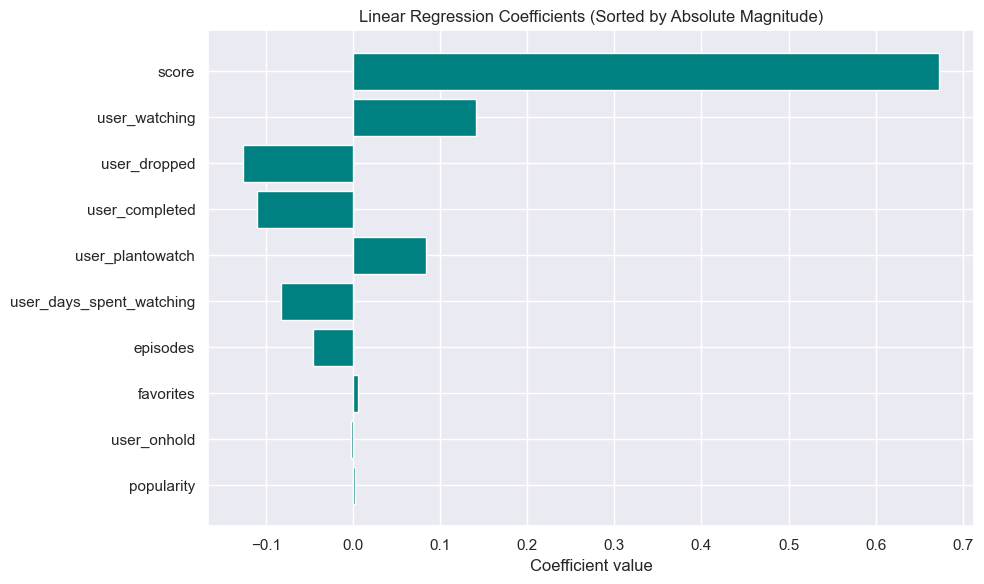

Model training complete.


In [23]:
X_train = train_df[FEATURE_COLS].copy()
X_val = val_df[FEATURE_COLS].copy()
X_test = test_df[FEATURE_COLS].copy()

y_train = train_df[TARGET_COL].copy()
y_val = val_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

# scaler fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": model.coef_,
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_df["feature"], coef_df["coefficient"], color="teal")
plt.xlabel("Coefficient value")
plt.title("Linear Regression Coefficients (Sorted by Absolute Magnitude)")
plt.tight_layout()
plt.show()

print("Model training complete.")

## V. Evaluation & Residual Diagnosis

We evaluate performance using:
- **RMSE**: penalizes larger errors more heavily
- **MAE**: average absolute error, directly interpretable in target units
- **R²**: variance explained by the model

Residual diagnostics are critical. Even when metrics look acceptable, residual patterns can reveal systematic bias, heteroscedasticity, or missed nonlinear structure.

Evaluation metrics:
Train  | RMSE: 1.6000 | MAE: 1.2130 | R2: 0.1639
Val    | RMSE: 1.6565 | MAE: 1.2256 | R2: 0.1672
Test   | RMSE: 1.6820 | MAE: 1.2296 | R2: 0.1694


,split,rmse,mae,r2
0,Train,1.600003,1.212953,0.163877
1,Val,1.656472,1.225574,0.167204
2,Test,1.681961,1.229640,0.169442



Generalization diagnostic:
Train R2 = 0.1639, Test R2 = 0.1694, Gap = -0.0056
Generalization looks reasonably stable for a baseline linear model.


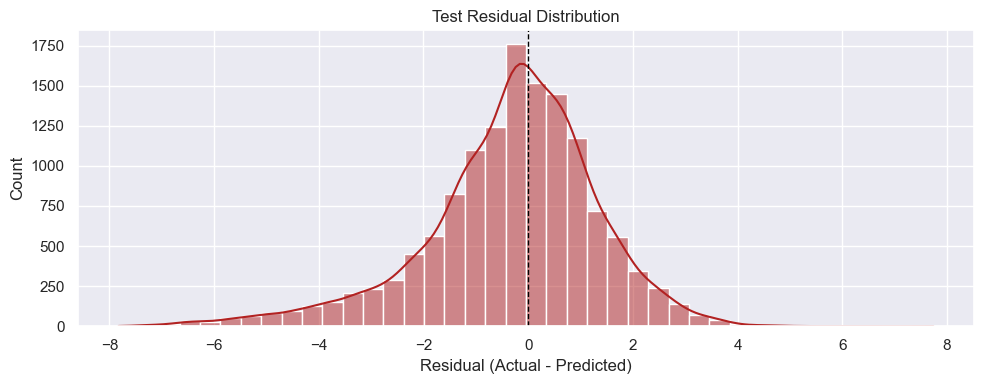

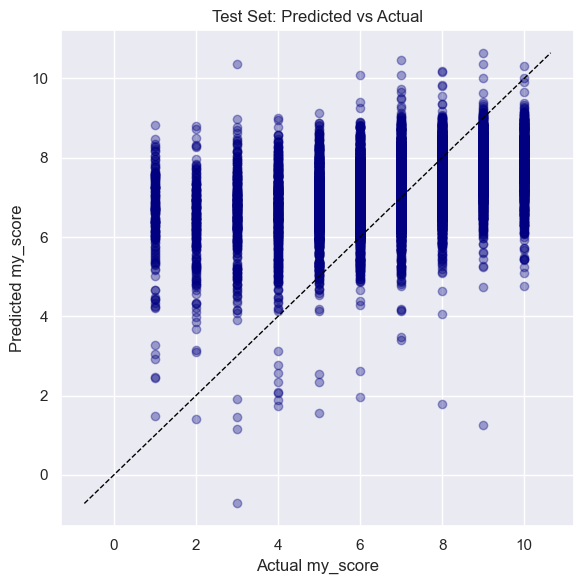

In [24]:
def evaluate_regression_split(name: str, y_true: pd.Series, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    print(f"{name:<6} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    return {"split": name, "rmse": rmse, "mae": mae, "r2": r2}


yhat_train = model.predict(X_train_scaled)
yhat_val = model.predict(X_val_scaled)
yhat_test = model.predict(X_test_scaled)

print("Evaluation metrics:")
results = []
results.append(evaluate_regression_split("Train", y_train, yhat_train))
results.append(evaluate_regression_split("Val", y_val, yhat_val))
results.append(evaluate_regression_split("Test", y_test, yhat_test))

results_df = pd.DataFrame(results)
display(results_df)

# explicit overfitting / underfitting diagnostics
train_r2 = results_df.loc[results_df["split"] == "Train", "r2"].iloc[0]
test_r2 = results_df.loc[results_df["split"] == "Test", "r2"].iloc[0]
r2_gap = train_r2 - test_r2

print("\nGeneralization diagnostic:")
print(f"Train R2 = {train_r2:.4f}, Test R2 = {test_r2:.4f}, Gap = {r2_gap:.4f}")
if r2_gap > 0.10:
    print("Potential overfitting detected: Train performance significantly exceeds Test.")
elif train_r2 < 0.10 and test_r2 < 0.10:
    print("Potential underfitting detected: both Train and Test R2 are low.")
else:
    print("Generalization looks reasonably stable for a baseline linear model.")

# Residual diagnostics on test set
residuals_test = y_test - yhat_test

plt.figure(figsize=(10, 4))
sns.histplot(residuals_test, bins=40, kde=True, color="firebrick")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Test Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.35, color="navy")
low = min(y_test.min(), yhat_test.min())
high = max(y_test.max(), yhat_test.max())
plt.plot([low, high], [low, high], linestyle="--", color="black", linewidth=1)
plt.xlabel("Actual my_score")
plt.ylabel("Predicted my_score")
plt.title("Test Set: Predicted vs Actual")
plt.tight_layout()
plt.show()

### VI. Summary and Conclusion
This notebook built a baseline Linear Regression model for anime rating prediction using a leakage-safe, time-aware pipeline.

The workflow included:
- strict data loading and health checks
- robust feature selection and numeric coercion
- chronological Train/Validation/Test splitting to avoid temporal leakage
- train-only scaling for proper evaluation hygiene
- baseline model training and residual diagnostics
- Core evaluation metrics RMSE, MAE, and R² were reported across splits, and residual plots were used to inspect model behavior beyond scalar metrics.

The Linear Regression baseline provides a stable and interpretable starting point for this recommendation task.
Results show that the model captures part of the variance in user ratings, but residual patterns and moderate R² indicate remaining nonlinear structure that linear assumptions cannot fully model.

This baseline is therefore valuable as:
- a reliable benchmark for model comparison
- a sanity check for data quality and split strategy
- a foundation for higher-capacity models such as Random Forest and Hybrid Neural Networks
Overall, the notebook confirms a production-safe baseline and justifies moving to more expressive models for stronger predictive performance.

